# Oil Prices And Geopolitics: Exploratory Data Analysis (2010 - 2026)

### 1. Imports And Data Loading


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [74]:
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

BRENT_COLOR  = '#1f77b4'
WTI_COLOR    = '#d62728'
GPR_COLOR    = '#e377c2'
VIX_COLOR    = '#ff7f0e'
SPREAD_COLOR = '#2ca02c'
EVENT_COLOR  = '#9467bd'

In [75]:
df = pd.read_csv("oil_geopolitics_dataset_2010_2026.csv")

In [76]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
 
print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range    : {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"Trading days  : {df['date'].nunique():,}")

Dataset shape : 4,047 rows × 23 columns
Date range    : 2010-02-17  →  2026-03-12
Trading days  : 4,047


In [77]:
df.head()

,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,...,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag
0,2010-02-17,76.2700,77.3300,80.3800,21.7200,80.7254,0.0078,0.0042,75.6800,73.0500,...,71.1900,0.0145,0.0197,0.0170,0.0193,-1.0600,none,none,0.0000,0
1,2010-02-18,77.7800,79.0600,80.4000,20.6300,80.7254,0.0198,0.0224,76.2700,72.9000,...,71.8900,0.0144,0.0200,0.0174,0.0198,-1.2800,none,none,0.0000,0
2,2010-02-19,78.1900,79.8100,80.6400,20.0200,80.7254,0.0053,0.0095,77.7800,75.6800,...,73.7500,0.0133,0.0198,0.0166,0.0196,-1.6200,none,none,0.0000,0
3,2010-02-22,78.6100,80.1600,80.5100,19.9400,80.7254,0.0054,0.0044,78.1900,76.2700,...,74.5200,0.0134,0.0198,0.0168,0.0196,-1.5500,none,none,0.0000,0
4,2010-02-23,77.2500,78.8600,80.8500,21.3700,80.7254,-0.0173,-0.0162,78.6100,77.7800,...,75.2800,0.0173,0.0200,0.0196,0.0198,-1.6100,none,none,0.0000,0


In [78]:
df.tail()

,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,...,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag
4042,2026-03-06,92.6900,90.9000,98.9900,29.4900,130.8877,0.0852,0.1221,85.4100,81.4000,...,65.4200,0.0337,0.0295,0.0453,0.0340,1.7900,none,none,0.0000,0
4043,2026-03-09,98.9600,94.7700,99.1800,25.5000,130.8877,0.0676,0.0426,92.6900,81.4000,...,65.2100,0.0295,0.0310,0.0394,0.0343,4.1900,blockade,Closure of Strait of Hormuz shipping lane,10.0000,1
4044,2026-03-10,87.8000,83.4500,98.8300,24.9300,130.8877,-0.1128,-0.1194,98.9600,85.4100,...,67.0200,0.0686,0.0386,0.0775,0.0421,4.3500,none,none,0.0000,0
4045,2026-03-11,91.9800,87.2500,99.2300,24.2300,130.8877,0.0476,0.0455,87.8000,92.6900,...,71.2300,0.0666,0.0391,0.0767,0.0424,4.7300,none,none,0.0000,0
4046,2026-03-12,95.7600,94.3100,99.4640,24.2300,130.8877,0.0411,0.0809,91.9800,98.9600,...,74.5600,0.0663,0.0395,0.0789,0.0443,1.4500,none,none,0.0000,0


In [79]:
# Check data types and missing values
df.dtypes

date                    datetime64[ns]
brent_price                    float64
wti_price                      float64
dxy_index                      float64
vix                            float64
gpr_index                      float64
brent_return                   float64
wti_return                     float64
brent_lag_1                    float64
brent_lag_3                    float64
brent_lag_7                    float64
wti_lag_1                      float64
wti_lag_3                      float64
wti_lag_7                      float64
brent_volatility_7d            float64
brent_volatility_30d           float64
wti_volatility_7d              float64
wti_volatility_30d             float64
brent_wti_spread               float64
event_type                      object
event_description               object
event_severity                 float64
event_flag                       int64
dtype: object

In [80]:
# Missing values count
df.isnull().sum()

date                    0
brent_price             0
wti_price               0
dxy_index               0
vix                     0
gpr_index               0
brent_return            0
wti_return              0
brent_lag_1             0
brent_lag_3             0
brent_lag_7             0
wti_lag_1               0
wti_lag_3               0
wti_lag_7               0
brent_volatility_7d     0
brent_volatility_30d    0
wti_volatility_7d       0
wti_volatility_30d      0
brent_wti_spread        0
event_type              0
event_description       0
event_severity          0
event_flag              0
dtype: int64

In [81]:
# Duplicate rows check on 'date' column
df.duplicated(subset='date').sum()

np.int64(0)

### 2. Correlation Analysis and Hypothesis Testing

Correlation matrix helps us understand how strongly variables co-move and reveals multicollinearity among features.

Hypothesis to test:
1. brent_price And wti_price - Strogly correlated
2. gpr_index And brent_volatility_7d - Positively correlated
3. dxy_index And brent_price - Negatively correlated 
4. vix And brent_volatility_7d - Positively correlated

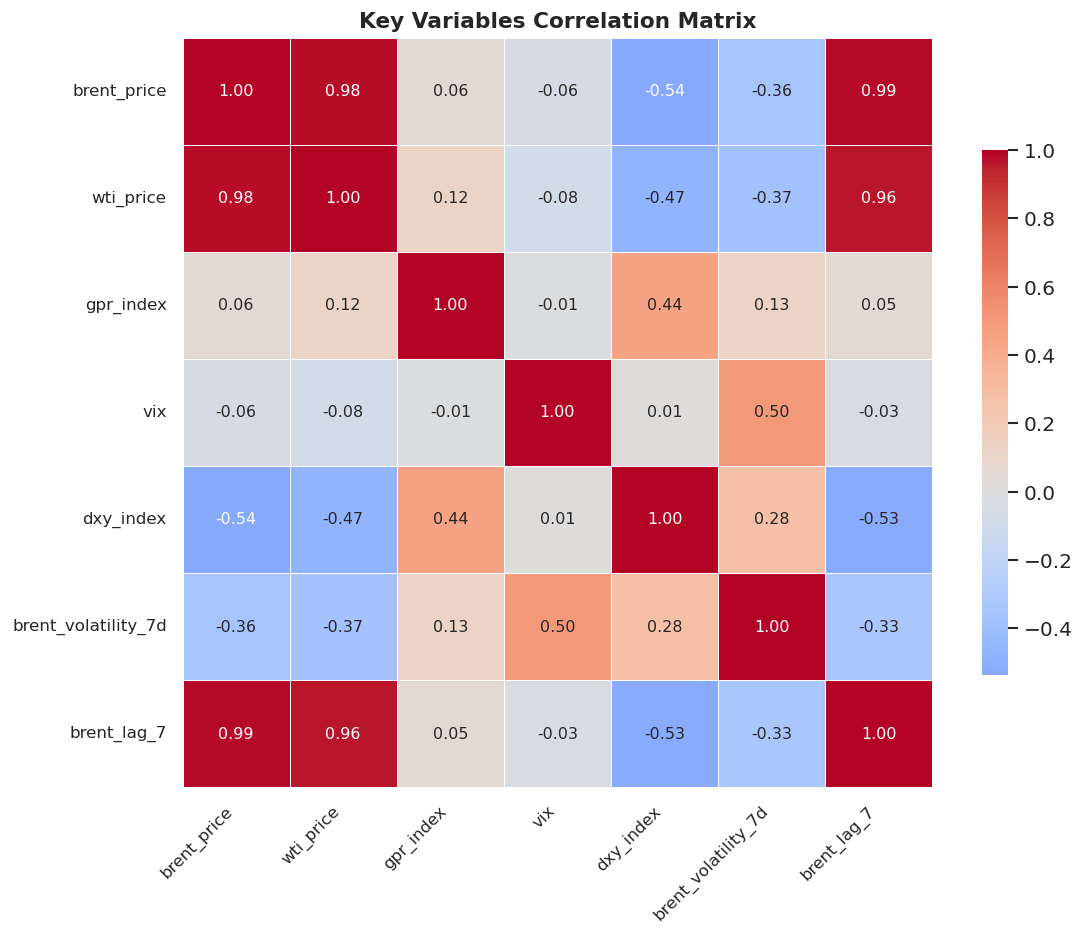

In [82]:
fig, ax = plt.subplots(figsize=(10, 8))

focus_cols = ['brent_price', 'wti_price', 'gpr_index', 'vix', 'dxy_index',
               'brent_volatility_7d', 'brent_lag_7']
focus_corr = df[focus_cols].corr()

sns.heatmap(focus_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 9.5}, ax=ax)

ax.set_title('Key Variables Correlation Matrix', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)

plt.tight_layout()
plt.show()

In [83]:
# Highlight key correlation pairs
print(" Notable Correlation Pairs")
print("─" * 55)
pairs = [
    ('brent_price',         'wti_price',             'Price co-movement'),
    ('brent_price',         'dxy_index',             'Oil vs. USD (expected negative)'),
    ('brent_price',         'gpr_index',             'Oil price vs. geopolitical risk'),
    ('gpr_index',           'brent_volatility_7d',   'GPR → Brent volatility'),
    ('gpr_index',           'vix',                   'GPR → Market fear (VIX)'),
    ('vix',                 'brent_volatility_7d',   'Market fear → oil volatility'),
]
for c1, c2, label in pairs:
    if c1 in df.columns and c2 in df.columns:
        r = df[[c1, c2]].corr().iloc[0, 1]
        print(f"  {label:<45} r = {r:+.4f}")

 Notable Correlation Pairs
───────────────────────────────────────────────────────
  Price co-movement                             r = +0.9785
  Oil vs. USD (expected negative)               r = -0.5361
  Oil price vs. geopolitical risk               r = +0.0555
  GPR → Brent volatility                        r = +0.1312
  GPR → Market fear (VIX)                       r = -0.0094
  Market fear → oil volatility                  r = +0.4962


### 3. Statistics

In [84]:
print("\nStatistical Summary:")
pd.set_option('display.float_format', '{:.4f}'.format)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
stats = df[numeric_cols].describe().T
stats['skewness'] = df[numeric_cols].skew()
stats['kurtosis'] = df[numeric_cols].kurt()

stats.round(4)


Statistical Summary:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
brent_price,4047.0000,77.6239,23.5293,19.3300,60.7850,75.1700,98.1550,127.9800,0.1319,-0.9002
wti_price,4047.0000,71.4175,20.7773,-37.6300,54.3400,71.1200,88.1800,123.7000,-0.0414,-0.6530
dxy_index,4047.0000,92.9090,9.2855,72.9300,82.7350,95.3100,99.1800,114.1100,-0.3463,-0.9577
vix,4047.0000,18.3932,6.8538,9.1400,13.7750,16.6500,21.0100,82.6900,2.4077,11.1552
gpr_index,4047.0000,102.5964,31.5592,58.4208,81.3896,93.5213,116.7163,318.9549,2.4409,11.8195
brent_return,4047.0000,0.0003,0.0224,-0.2440,-0.0097,0.0005,0.0110,0.2102,-0.3874,12.8476
wti_return,4047.0000,-0.0005,0.0581,-3.0597,-0.0115,0.0009,0.0124,0.3766,-38.5617,1957.3586
brent_lag_1,4047.0000,77.6190,23.5276,19.3300,60.7850,75.1700,98.1550,127.9800,0.1324,-0.8995
brent_lag_3,4047.0000,77.6106,23.5262,19.3300,60.7850,75.1700,98.1550,127.9800,0.1334,-0.8989
brent_lag_7,4047.0000,77.5923,23.5231,19.3300,60.7850,75.1300,98.1350,127.9800,0.1355,-0.8976


In [85]:
print(" Key Highlights")
print("─" * 50)
print(f"  Brent avg price     : ${df['brent_price'].mean():.2f}/barrel")
print(f"  WTI avg price       : ${df['wti_price'].mean():.2f}/barrel")
print(f"  Brent all-time high : ${df['brent_price'].max():.2f}  ({df.loc[df['brent_price'].idxmax(), 'date'].date()})")
print(f"  WTI all-time high   : ${df['wti_price'].max():.2f}  ({df.loc[df['wti_price'].idxmax(), 'date'].date()})")
print(f"  Brent all-time low  : ${df['brent_price'].min():.2f}  ({df.loc[df['brent_price'].idxmin(), 'date'].date()})")
print(f"  WTI all-time low    : ${df['wti_price'].min():.2f}  ({df.loc[df['wti_price'].idxmin(), 'date'].date()})")
print(f"  Avg GPR index       : {df['gpr_index'].mean():.1f}")
print(f"  Max GPR index       : {df['gpr_index'].max():.1f}  ({df.loc[df['gpr_index'].idxmax(), 'date'].date()})")
print(f"  Avg VIX             : {df['vix'].mean():.1f}")
print(f"  Max VIX             : {df['vix'].max():.1f}  ({df.loc[df['vix'].idxmax(), 'date'].date()})")


 Key Highlights
──────────────────────────────────────────────────
  Brent avg price     : $77.62/barrel
  WTI avg price       : $71.42/barrel
  Brent all-time high : $127.98  (2022-03-08)
  WTI all-time high   : $123.70  (2022-03-08)
  Brent all-time low  : $19.33  (2020-04-21)
  WTI all-time low    : $-37.63  (2020-04-20)
  Avg GPR index       : 102.6
  Max GPR index       : 319.0  (2022-03-01)
  Avg VIX             : 18.4
  Max VIX             : 82.7  (2020-03-16)


### 4. Time Series Analysis and Visualization

Plot core market indicators over 2010-2026 with key geopolitical events:
- Brent Crude Price (USD/barrel)
- WTI Crude Price (USD/barrel)              
- Geopolitical Risk Index (GPR)
- VIX Index

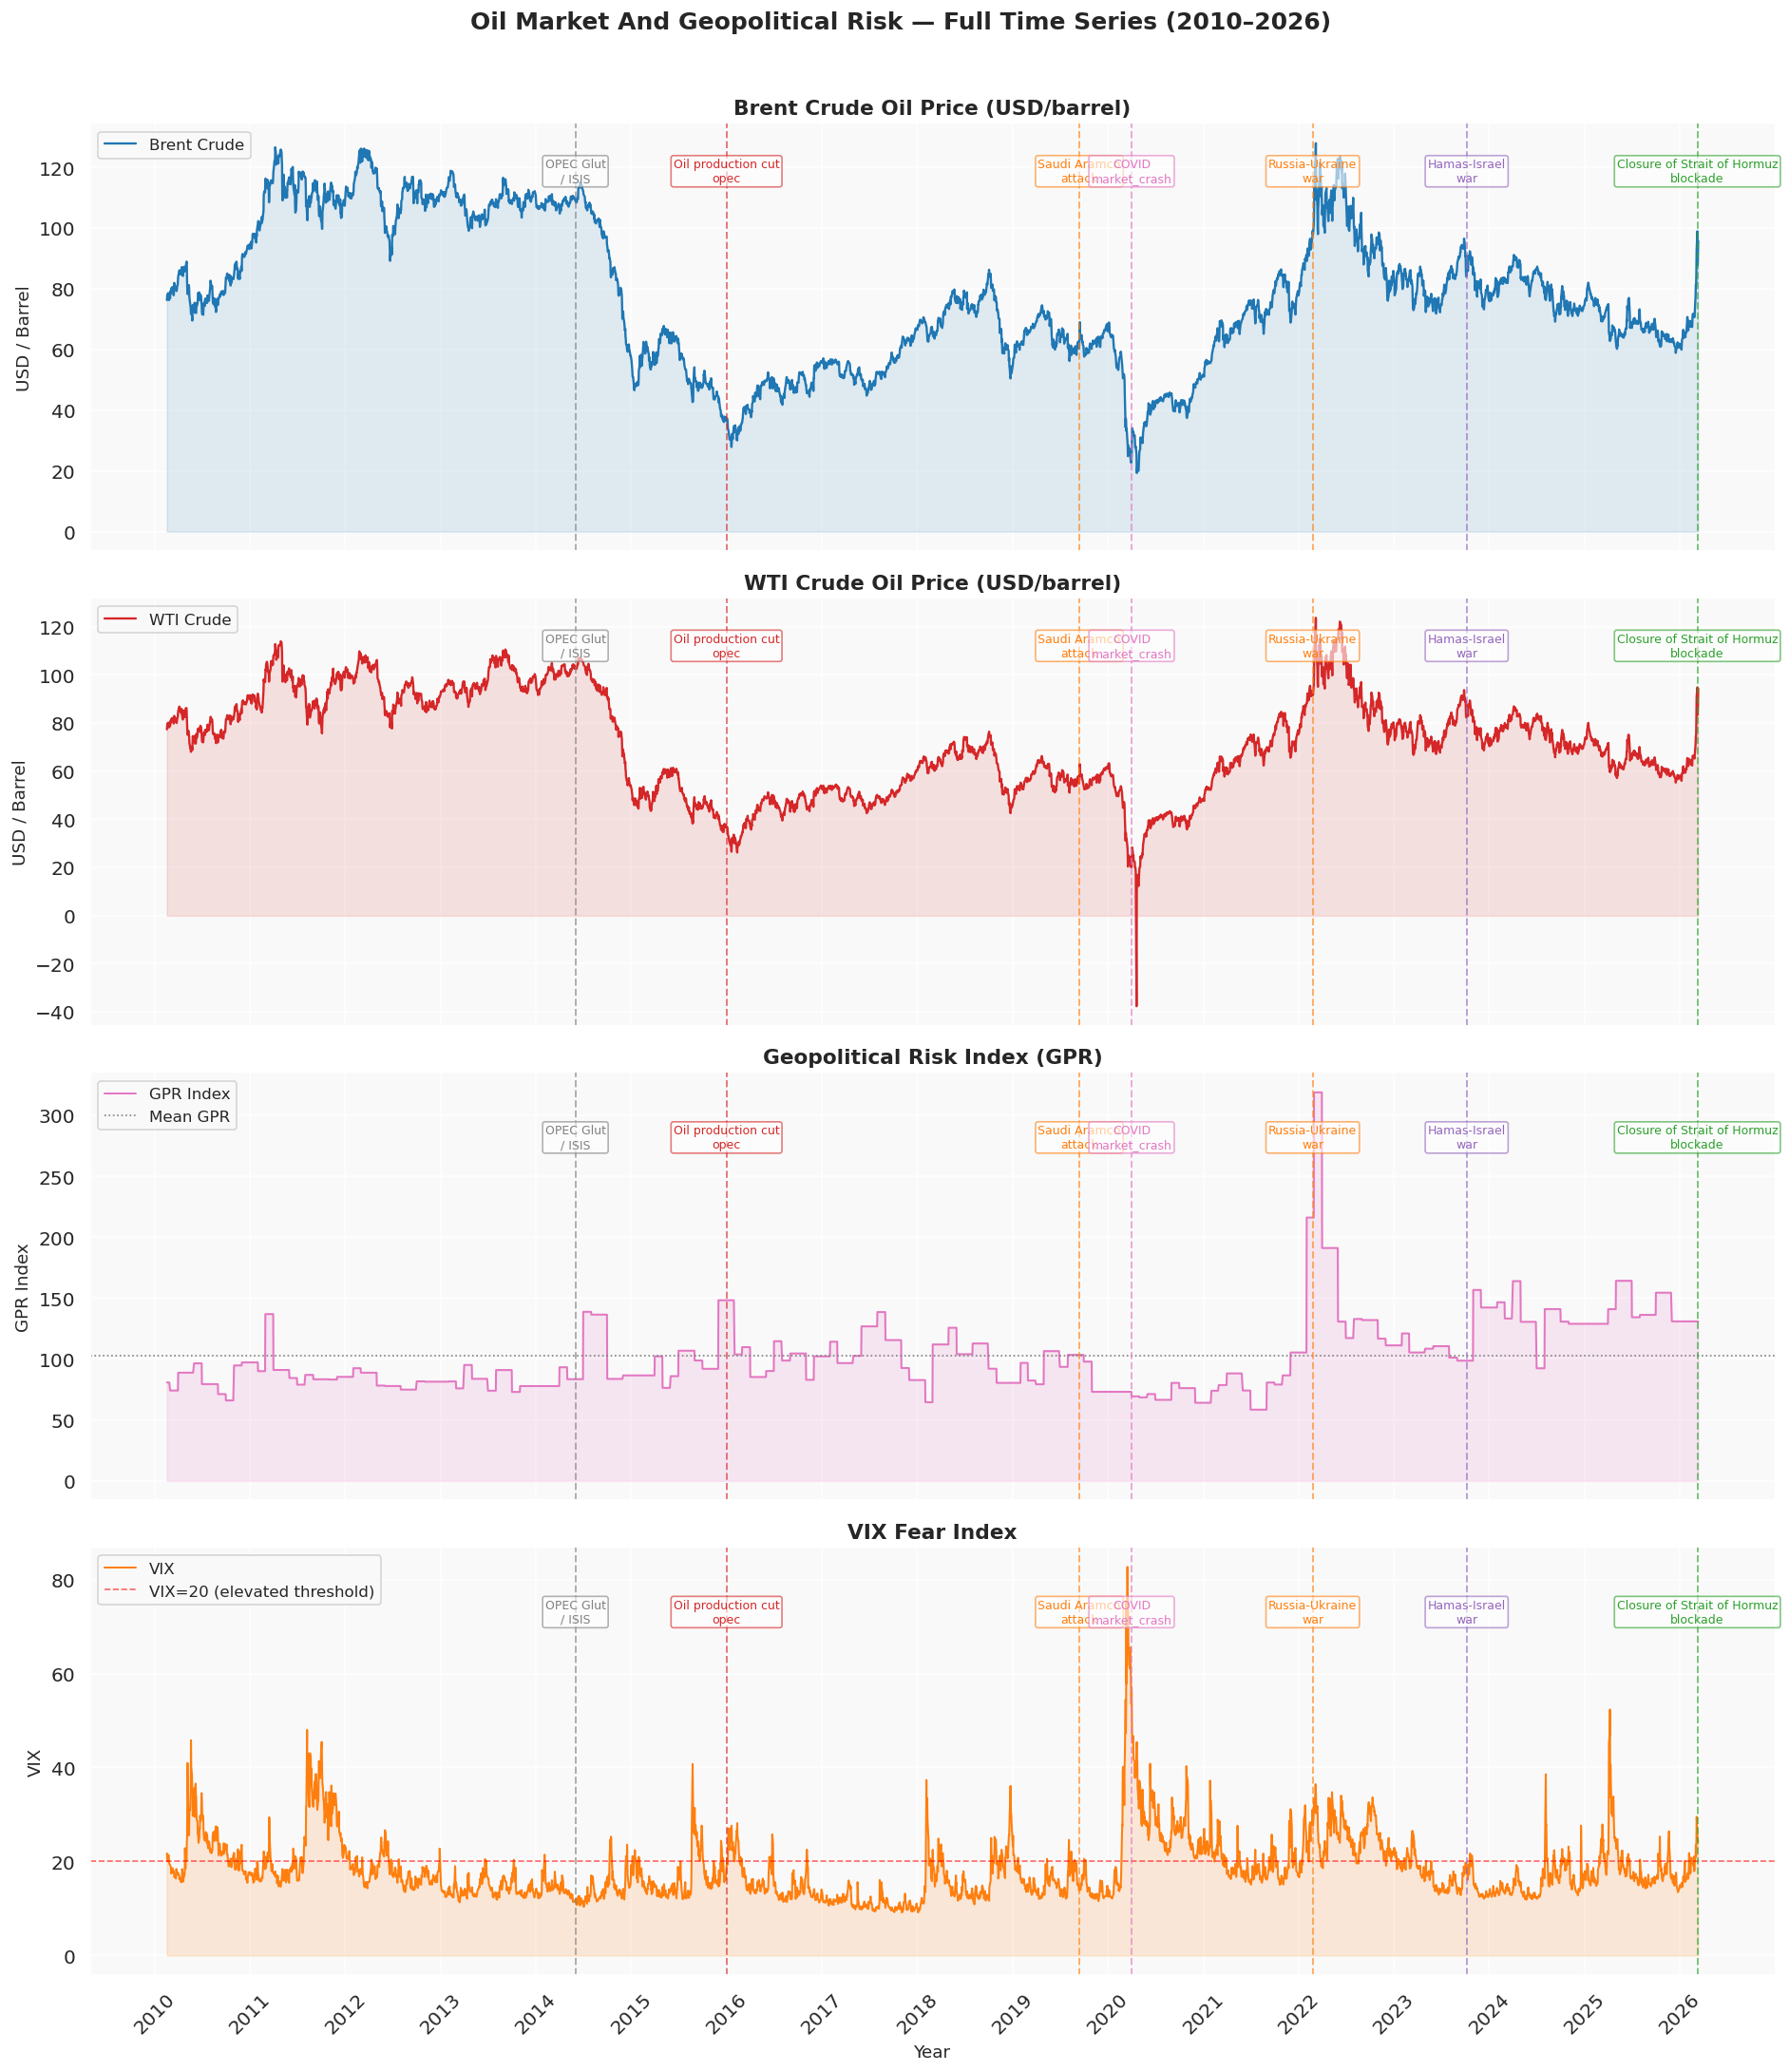

In [86]:
fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)

# ── Common event annotations ───────────────────────────────────────────────────
annotations = {
    '2014-06-01': ('OPEC Glut\n/ ISIS', 'gray'),
    '2016-01-01': ('Oil production cut\nopec',  '#d62728'),
    '2019-09-14': ('Saudi Aramco\nattack', '#ff7f0e'),
    '2020-04-01': ('COVID\nmarket_crash',      '#e377c2'),
    '2022-02-24': ('Russia-Ukraine\nwar', '#ff7f0e'),
    '2023-10-07': ('Hamas-Israel\nwar',  '#9467bd'),
    '2026-03-09': ('Closure of Strait of Hormuz\nblockade', '#2ca02c'),
}

def add_events(ax, yloc_frac=0.92):
    ymin, ymax = ax.get_ylim()
    ypos = ymin + (ymax - ymin) * yloc_frac
    for date_str, (label, color) in annotations.items():
        try:
            xpos = pd.Timestamp(date_str)
            ax.axvline(xpos, color=color, lw=1.2, ls='--', alpha=0.6)
            ax.text(xpos, ypos, label, fontsize=7.5, color=color,
                    ha='center', va='top', rotation=0,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6, edgecolor=color))
        except Exception:
            pass

# ── 1. Brent Price ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df['date'], df['brent_price'], color=BRENT_COLOR, lw=1.4, label='Brent Crude')
ax.fill_between(df['date'], df['brent_price'], alpha=0.12, color=BRENT_COLOR)
ax.set_ylabel('USD / Barrel', fontsize=11)
ax.set_title('Brent Crude Oil Price (USD/barrel)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
add_events(ax)

# ── 2. WTI Price ───────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df['date'], df['wti_price'], color=WTI_COLOR, lw=1.4, label='WTI Crude')
ax.fill_between(df['date'], df['wti_price'], alpha=0.12, color=WTI_COLOR)
ax.set_ylabel('USD / Barrel', fontsize=11)
ax.set_title('WTI Crude Oil Price (USD/barrel)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
add_events(ax)

# ── 3. GPR Index ───────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(df['date'], df['gpr_index'], color=GPR_COLOR, lw=1.2, label='GPR Index')
ax.fill_between(df['date'], df['gpr_index'], alpha=0.15, color=GPR_COLOR)
ax.axhline(df['gpr_index'].mean(), color='gray', lw=1, ls=':', label='Mean GPR')
ax.set_ylabel('GPR Index', fontsize=11)
ax.set_title('Geopolitical Risk Index (GPR)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
add_events(ax, yloc_frac=0.88)

# ── 4. VIX ─────────────────────────────────────────────────────────────────────
ax = axes[3]
ax.plot(df['date'], df['vix'], color=VIX_COLOR, lw=1.2, label='VIX')
ax.fill_between(df['date'], df['vix'], alpha=0.15, color=VIX_COLOR)
ax.axhline(20, color='red', lw=1, ls='--', alpha=0.6, label='VIX=20 (elevated threshold)')
ax.set_ylabel('VIX', fontsize=11)
ax.set_title('VIX Fear Index', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
add_events(ax, yloc_frac=0.88)

# ── Format x-axis ──────────────────────────────────────────────────────────────
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45)

fig.suptitle('Oil Market And Geopolitical Risk — Full Time Series (2010–2026)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [87]:
print(" Key Highlights")
print("─" * 50)

print("""
2011–2014
→ Brent traded between $89–$127.
  Sustained premium above $100 driven by Arab Spring tensions and strong emerging market demand.

2014–2016
→ Brent fell from ~$115 to a low of $27.9. 

2016–2019
→ Brent ranged $27–$86.
  Punctuated by US-Iran tensions and OPEC+ supply cuts.

2020 — COVID Crash
→ Brent hit $19.3.
  WTI went negative (-$37.6) in April 2020 due to storage constraints.

2022 — Russia-Ukraine War
→ Brent surged to $128.
  GPR index hit its highest ever level (319) 

2023–2024
→ Brent ranged $69–$97. 
  Hamas-Israel conflict kept markets reactive.

2026 — Strait of Hormuz Closure
→ Brent spiked sharply.
""")


 Key Highlights
──────────────────────────────────────────────────

2011–2014
→ Brent traded between $89–$127.
  Sustained premium above $100 driven by Arab Spring tensions and strong emerging market demand.

2014–2016
→ Brent fell from ~$115 to a low of $27.9. 

2016–2019
→ Brent ranged $27–$86.
  Punctuated by US-Iran tensions and OPEC+ supply cuts.

2020 — COVID Crash
→ Brent hit $19.3.
  WTI went negative (-$37.6) in April 2020 due to storage constraints.

2022 — Russia-Ukraine War
→ Brent surged to $128.
  GPR index hit its highest ever level (319) 

2023–2024
→ Brent ranged $69–$97. 
  Hamas-Israel conflict kept markets reactive.

2026 — Strait of Hormuz Closure
→ Brent spiked sharply.



### 5. Volatility Analysis

Volatility is a key measure of market uncertainty. We will analyze:
1. How does volatility evolve over 7days and 30days?
2. Observe crisis periods and see if volatility spikes around major geopolitical events.

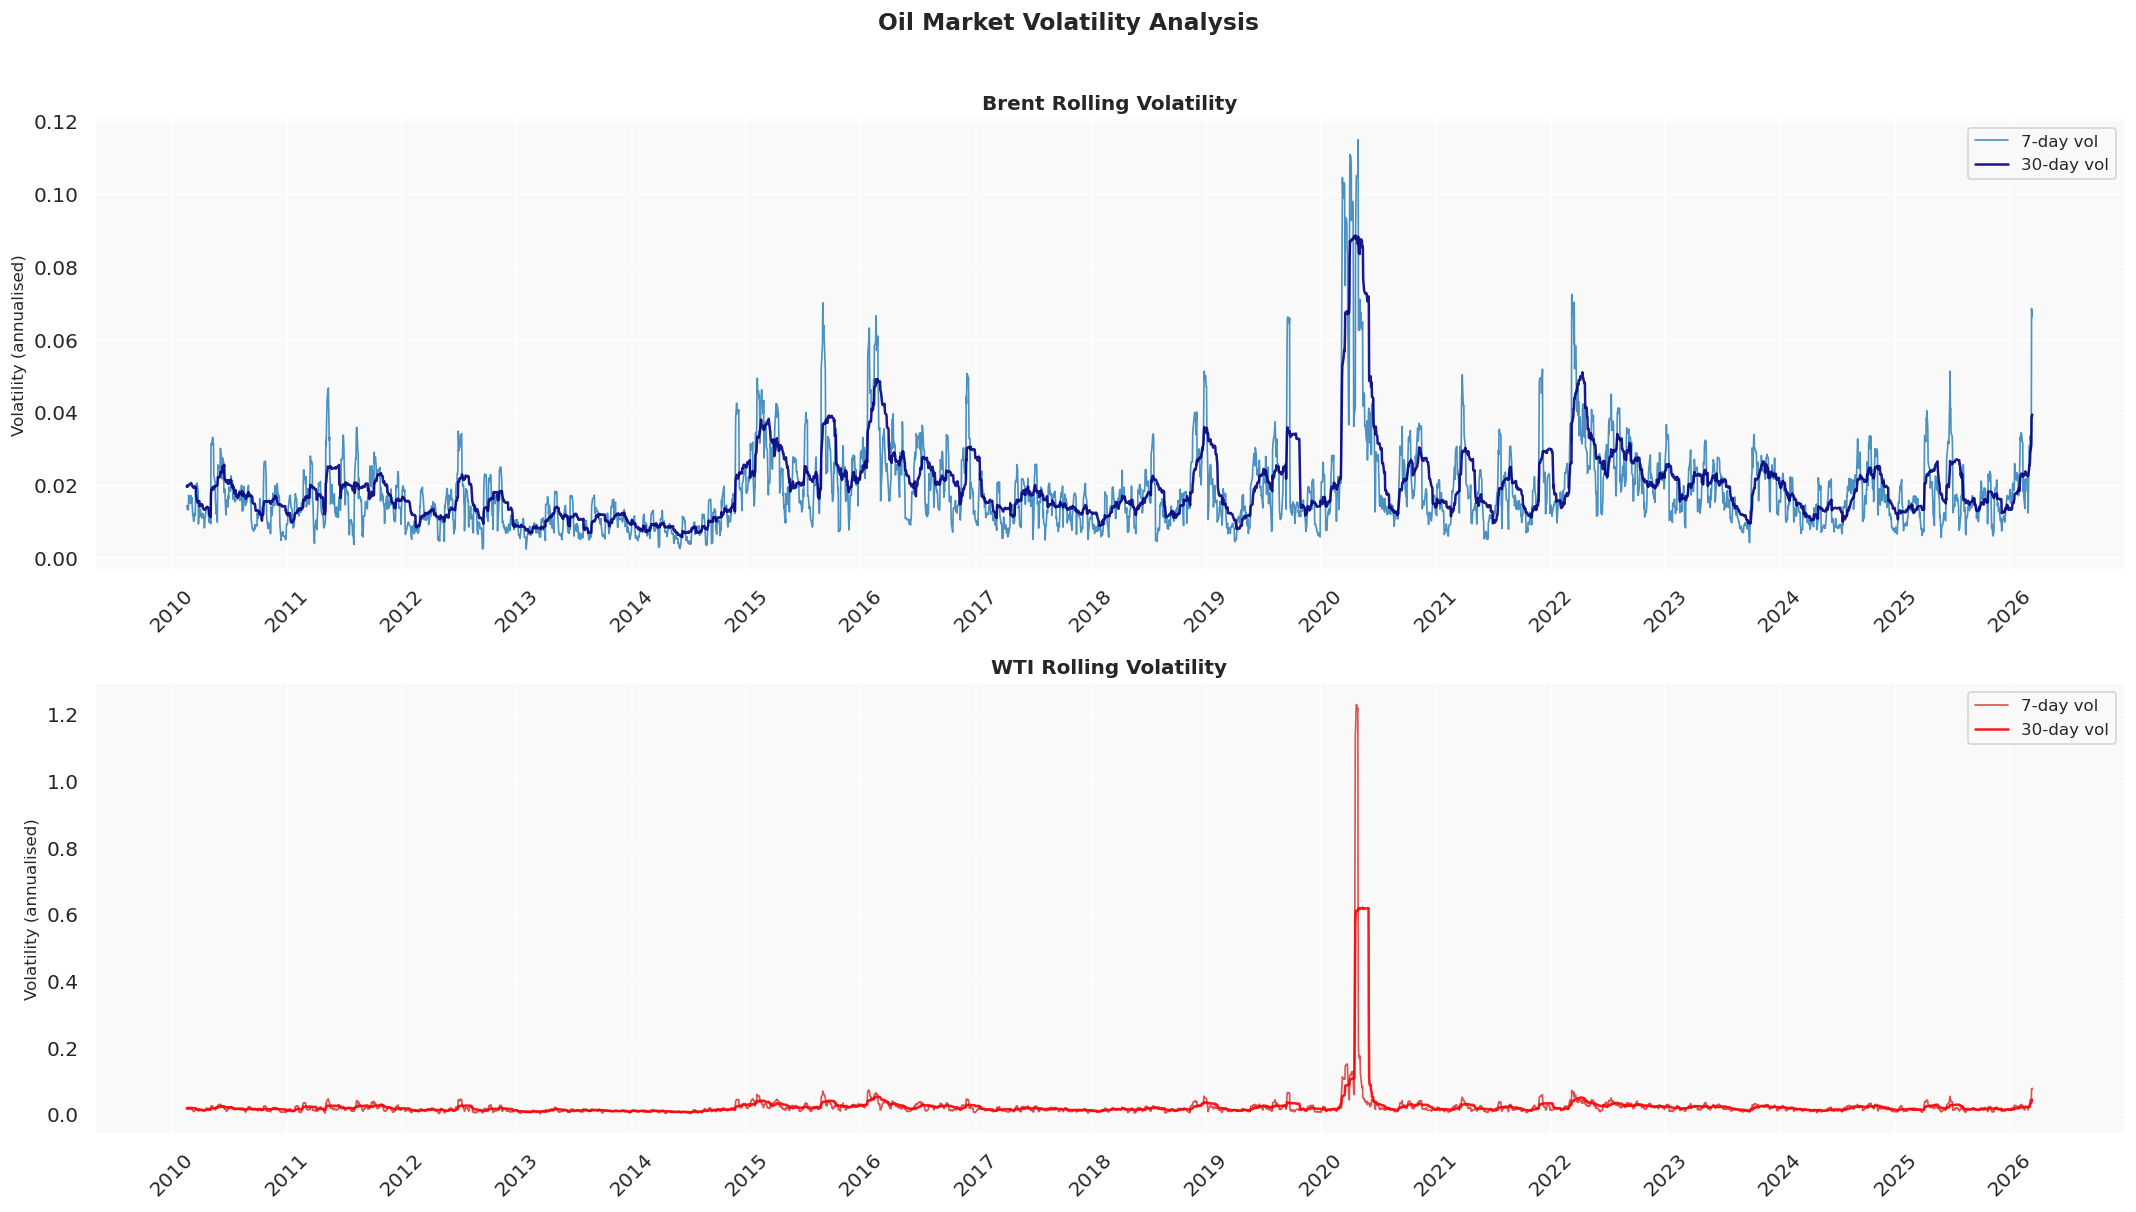

In [88]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# ── 1. Brent 7d vs 30d Volatility ─────────────────────────────────────────────
ax = axes[0]
ax.plot(df['date'], df['brent_volatility_7d'], color=BRENT_COLOR, lw=1.0, alpha=0.8, label='7-day vol')
ax.plot(df['date'], df['brent_volatility_30d'], color='navy', lw=1.5, alpha=0.9, label='30-day vol')
ax.set_title('Brent Rolling Volatility', fontsize=12, fontweight='bold')
ax.set_ylabel('Volatility (annualised)', fontsize=10)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ── 2. WTI 7d vs 30d Volatility ───────────────────────────────────────────────
ax = axes[1]
ax.plot(df['date'], df['wti_volatility_7d'], color=WTI_COLOR, lw=1.0, alpha=0.8, label='7-day vol')
ax.plot(df['date'], df['wti_volatility_30d'], color='red', lw=1.5, alpha=0.9, label='30-day vol')
ax.set_title('WTI Rolling Volatility', fontsize=12, fontweight='bold')
ax.set_ylabel('Volatility (annualised)', fontsize=10)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)


fig.suptitle('Oil Market Volatility Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [89]:
print(" Top 10 Highest Brent 7-day Volatility Days")
print("─" * 60)
top_vol = df.nlargest(10, 'brent_volatility_7d')[
    ['date', 'brent_price', 'brent_volatility_7d', 'gpr_index', 'event_flag', 'event_description']
].reset_index(drop=True)
print(top_vol.to_string())
print(" Top 10 Highest WTI 7-day Volatility Days")
print("─" * 60)
top_vol = df.nlargest(10, 'wti_volatility_7d')[
    ['date', 'wti_price', 'wti_volatility_7d', 'gpr_index', 'event_flag', 'event_description']
].reset_index(drop=True)
print(top_vol.to_string())

 Top 10 Highest Brent 7-day Volatility Days
────────────────────────────────────────────────────────────
        date  brent_price  brent_volatility_7d  gpr_index  event_flag event_description
0 2020-04-29      22.5400               0.1149    69.3394           0              none
1 2020-04-03      34.1100               0.1109    69.3394           0              none
2 2020-04-06      33.0500               0.1101    69.3394           0              none
3 2020-04-07      31.8700               0.1078    69.3394           0              none
4 2020-04-28      20.4600               0.1059    69.3394           0              none
5 2020-04-24      21.4400               0.1051    69.3394           0              none
6 2020-04-27      19.9900               0.1046    69.3394           0              none
7 2020-03-10      37.2200               0.1045    73.0784           0              none
8 2020-04-23      21.3300               0.1045    69.3394           0              none
9 2020-03-16   

### 6. Geopolitical Event Impact Analysis

Different event_types are expected to have different impacts on oil prices. We will analyze 
1. How oil prices change around events? — using a rolling event window approach
2. How volatility react to events? — comparing event-day vs. non-event volatility

In [90]:
events_df = df[df['event_flag'] == 1].copy()
non_events_df = df[df['event_flag'] == 0].copy()

print(f" Total event days    : {len(events_df):,}")
print(f" Non-event days      : {len(non_events_df):,}")
print(f"\n Event type counts:")
if 'event_type' in df.columns:
    print(df[df['event_flag']==1]['event_type'].value_counts().to_string())

 Total event days    : 25
 Non-event days      : 4,022

 Event type counts:
event_type
sanctions            6
conflict             4
war                  3
opec                 3
blockade             2
disaster             1
annexation           1
diplomatic_crisis    1
market_crash         1
blockage             1
energy_crisis        1
market_shift         1


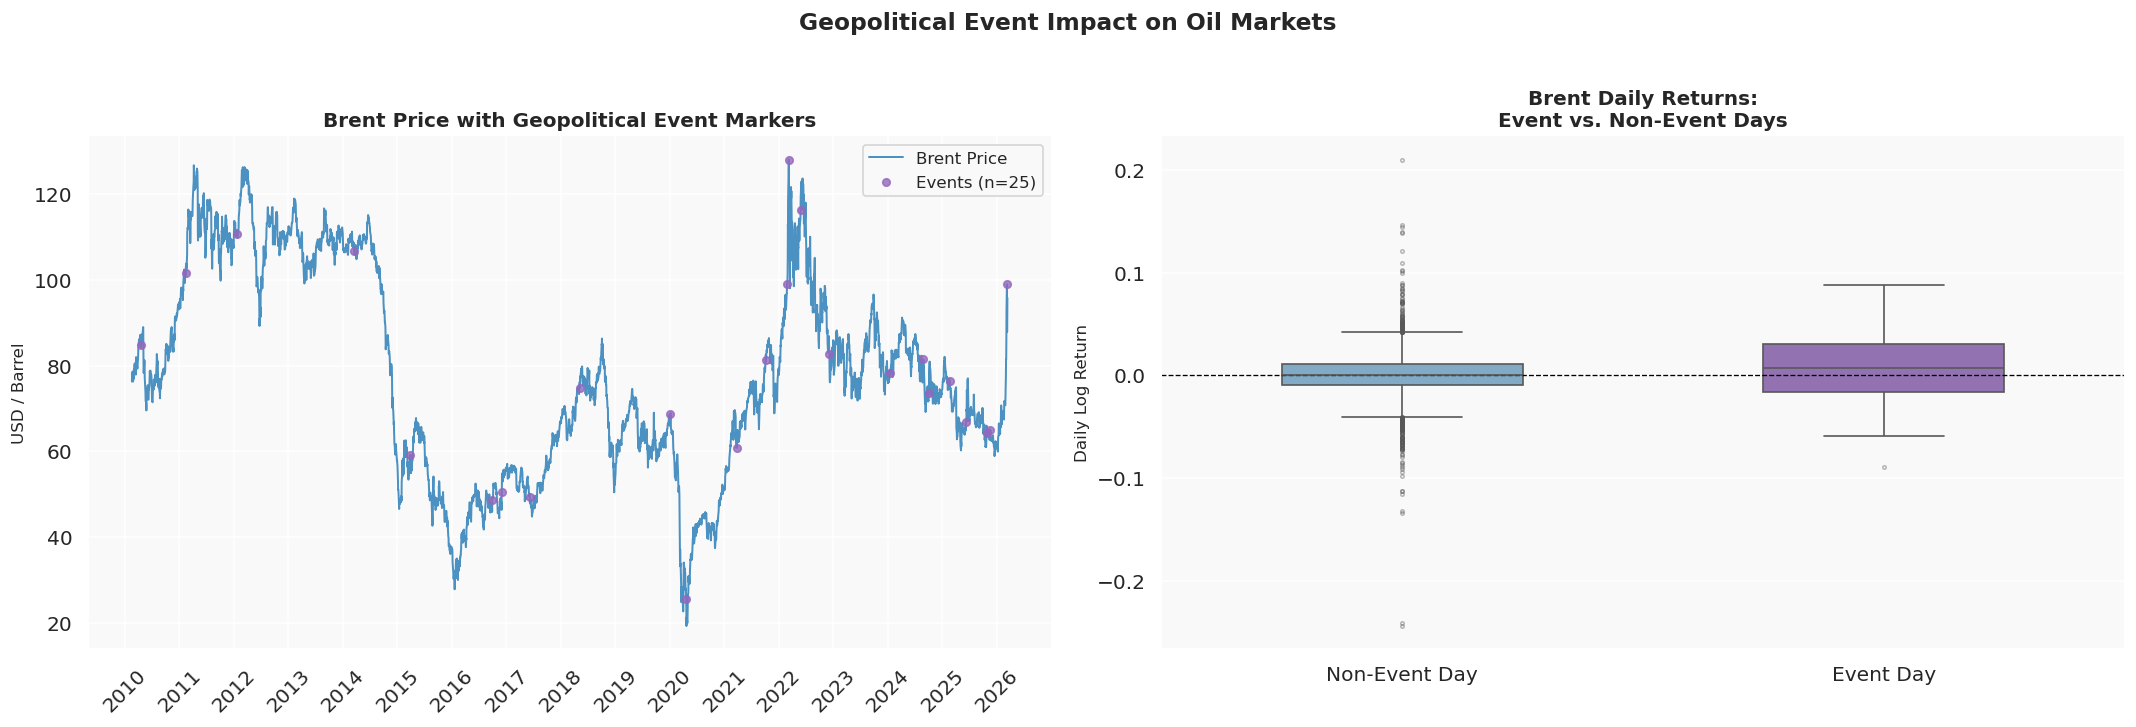

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── 1. Event markers on Brent price chart ─────────────────────────────────────
ax = axes[0]
ax.plot(df['date'], df['brent_price'], color=BRENT_COLOR, lw=1.2, alpha=0.8, label='Brent Price')
ax.scatter(events_df['date'], events_df['brent_price'],
           color=EVENT_COLOR, s=20, zorder=5, alpha=0.8, label=f'Events (n={len(events_df):,})')
ax.set_title('Brent Price with Geopolitical Event Markers', fontsize=12, fontweight='bold')
ax.set_ylabel('USD / Barrel', fontsize=10)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ── 2. Box plot: Brent returns on event vs. non-event days ────────────────────
ax = axes[1]
df_box = df[['brent_return', 'event_flag']].dropna()
df_box['Day Type'] = df_box['event_flag'].map({0: 'Non-Event Day', 1: 'Event Day'})
sns.boxplot(x='Day Type', y='brent_return', data=df_box, ax=ax,
            palette=['#74add1', EVENT_COLOR], width=0.5,
            flierprops=dict(marker='o', markersize=2, alpha=0.4))
ax.set_title('Brent Daily Returns:\nEvent vs. Non-Event Days', fontsize=12, fontweight='bold')
ax.set_ylabel('Daily Log Return', fontsize=10)
ax.set_xlabel('')
ax.axhline(0, color='black', lw=0.8, ls='--')

plt.suptitle('Geopolitical Event Impact on Oil Markets', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [92]:
df['event_type'].unique()

array(['none', 'disaster', 'war', 'sanctions', 'annexation', 'opec',
       'diplomatic_crisis', 'conflict', 'market_crash', 'blockage',
       'energy_crisis', 'blockade', 'market_shift'], dtype=object)

In [93]:
if 'event_type' in df.columns and df['event_flag'].sum() > 0:
    event_analysis = df[df['event_flag'] == 1].groupby('event_type').agg(
        count=('event_flag', 'count'),
        mean_brent_return=('brent_return', 'mean'),
        std_brent_return=('brent_return', 'std'),
        mean_abs_return=('brent_return', lambda x: x.abs().mean()),
        mean_volatility=('brent_volatility_30d', 'mean'),
        mean_severity=('event_severity', 'mean'),
    ).round(5).sort_values('mean_abs_return', ascending=False)

    print(" Oil Market Response by Event Type")
    print("─" * 80)
    print(event_analysis.to_string())

 Oil Market Response by Event Type
────────────────────────────────────────────────────────────────────────────────
                   count  mean_brent_return  std_brent_return  mean_abs_return  mean_volatility  mean_severity
event_type                                                                                                    
market_crash           1            -0.0894               NaN           0.0894           0.0883        10.0000
blockage               1            -0.0593               NaN           0.0593           0.0254         8.0000
opec                   3             0.0483            0.0463           0.0500           0.0221         8.0000
blockade               2             0.0491            0.0263           0.0491           0.0248         9.0000
war                    3             0.0191            0.0312           0.0284           0.0211         8.6667
sanctions              6            -0.0081            0.0333           0.0267           0.0204         7.8

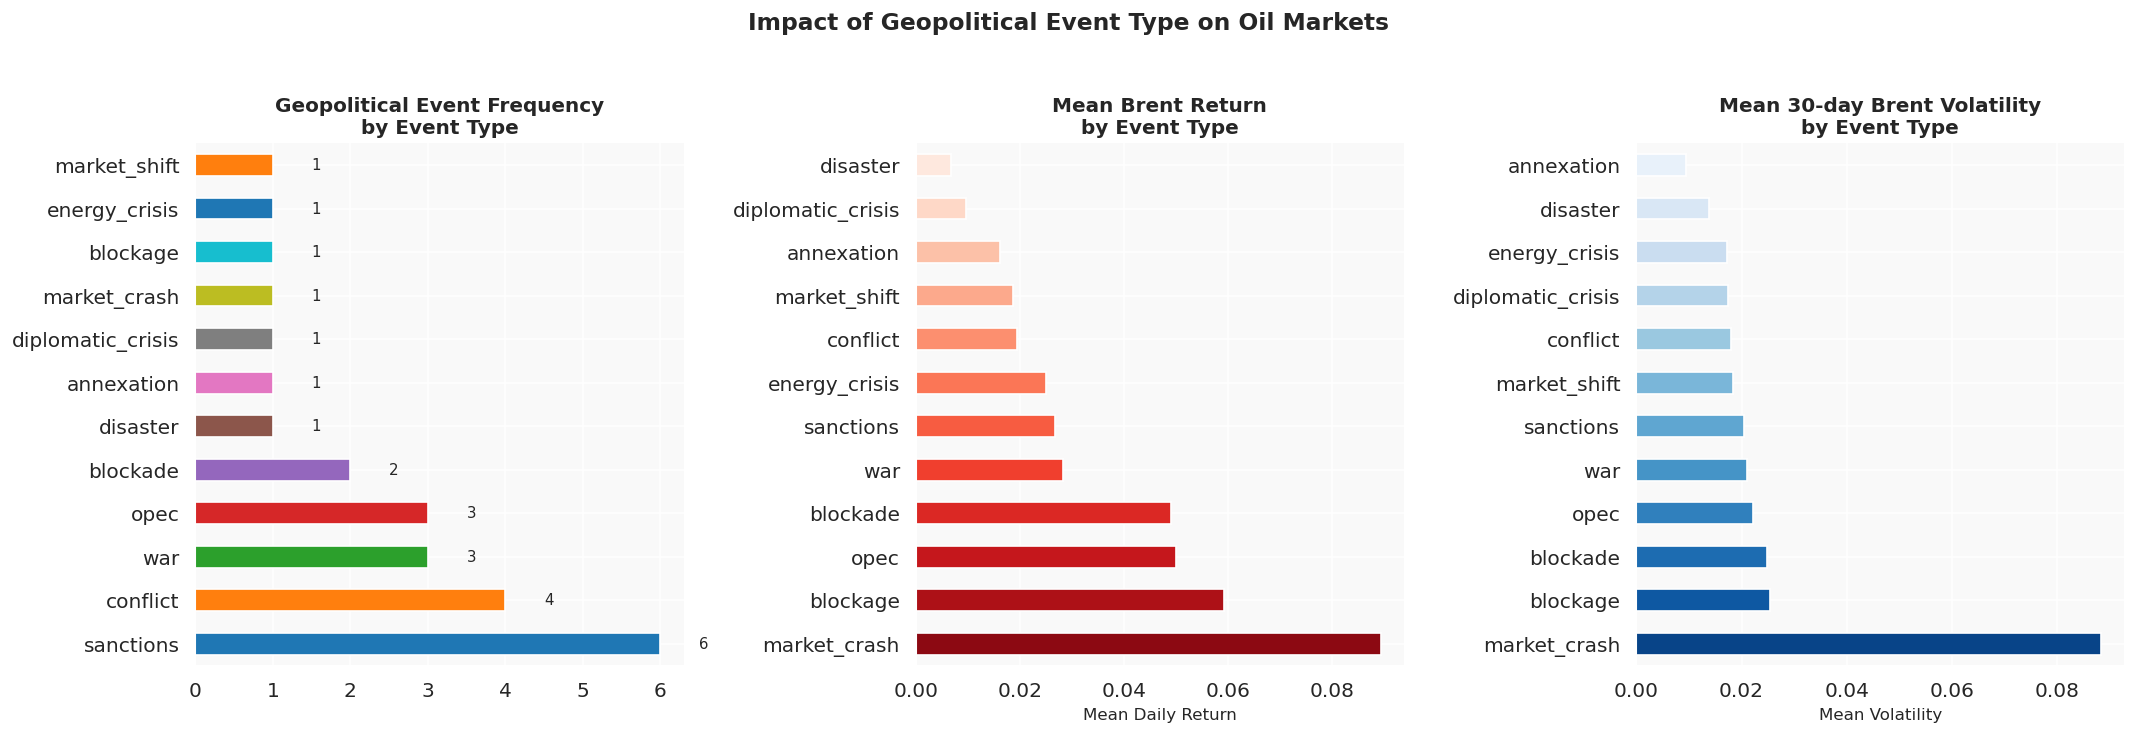

In [94]:
if 'event_type' in df.columns and df['event_flag'].sum() > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    event_types = df[df['event_flag'] == 1]['event_type'].value_counts()

    # ── 1. Event frequency bar chart ──────────────────────────────────────────
    ax = axes[0]
    event_types.plot(kind='barh', ax=ax, color=sns.color_palette('tab10', len(event_types)))
    ax.set_title('Geopolitical Event Frequency\nby Event Type', fontsize=12, fontweight='bold')
    ax.set_ylabel('')
    for i, v in enumerate(event_types.values):
        ax.text(v + 0.5, i, str(v), va='center', fontsize=9)

    # ── 2. Mean return by event type ────────────────────────────────────────
    ax = axes[1]
    ev_df = df[df['event_flag'] == 1].copy()
    ev_df['abs_return'] = ev_df['brent_return'].abs()
    type_return = ev_df.groupby('event_type')['abs_return'].mean().sort_values(ascending=False)
    colors = sns.color_palette('Reds_r', len(type_return))
    type_return.plot(kind='barh', ax=ax, color=colors)
    ax.set_title('Mean Brent Return\nby Event Type', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Daily Return', fontsize=10)
    ax.set_ylabel('')

    # ── 3. Mean 30d volatility by event type ──────────────────────────────────
    ax = axes[2]
    type_vol = ev_df.groupby('event_type')['brent_volatility_30d'].mean().sort_values(ascending=False).dropna()
    colors = sns.color_palette('Blues_r', len(type_vol))
    type_vol.plot(kind='barh', ax=ax, color=colors)
    ax.set_title('Mean 30-day Brent Volatility\nby Event Type', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Volatility', fontsize=10)
    ax.set_ylabel('')

    plt.suptitle('Impact of Geopolitical Event Type on Oil Markets', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### 7. Annual And Temporal Patterns Analysis

Look at how oil prices have evolved year by year, and quanitify the average price and volatility for each year. 

In [95]:
df['year'] = df['date'].dt.year

annual = df.groupby('year').agg(
    brent_mean=('brent_price', 'mean'),
    brent_std=('brent_price', 'std'),
    wti_mean=('wti_price', 'mean'),
    vix_mean=('vix', 'mean'),
    gpr_mean=('gpr_index', 'mean'),
).round(2)

print(" Annual Market Summary")
print("─" * 80)
print(annual.to_string())

 Annual Market Summary
────────────────────────────────────────────────────────────────────────────────
      brent_mean  brent_std  wti_mean  vix_mean  gpr_mean
year                                                     
2010     81.0400     5.7400   79.9700   22.6400   83.4800
2011    110.9500     6.9700   95.1100   24.2000   91.3000
2012    111.7600     7.8300   94.2100   17.8000   81.8800
2013    108.7200     4.2500   98.0500   14.2300   82.1400
2014     99.3500    14.6200   92.9100   14.1700   96.8500
2015     53.5000     8.0500   48.7600   16.6700   97.7300
2016     45.1300     6.7000   43.4100   15.8700  102.2000
2017     54.7300     4.9900   50.8500   11.0900  109.5300
2018     71.7700     6.9000   64.9500   16.6400   99.0600
2019     64.1600     4.1600   57.0400   15.3900   91.4300
2020     43.0900    10.2500   39.3400   29.2500   71.4400
2021     70.9500     7.8300   68.1100   19.6600   78.0900
2022     98.9700    11.7600   94.3300   25.6200  158.8100
2023     82.1900     5.580

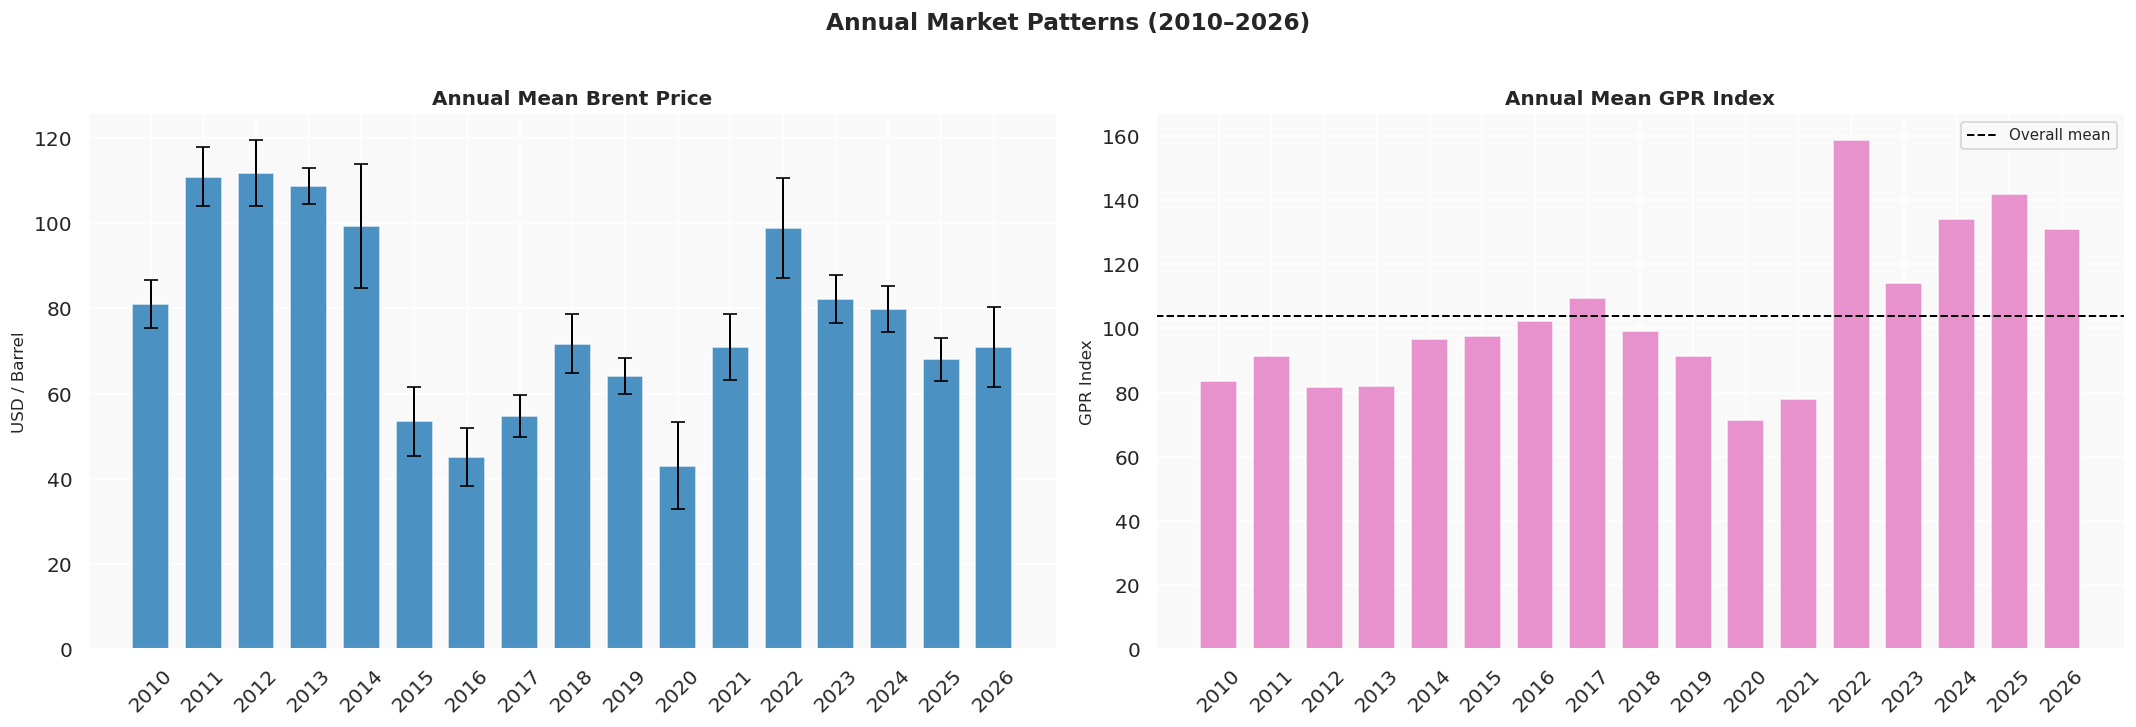

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

years = annual.index.tolist()
x = np.arange(len(years))

# ── 1. Annual mean Brent price ─────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(years, annual['brent_mean'], color=BRENT_COLOR, alpha=0.8, width=0.7)
ax.errorbar(years, annual['brent_mean'], yerr=annual['brent_std'],
            fmt='none', color='black', capsize=4, lw=1.2)
ax.set_title('Annual Mean Brent Price', fontsize=12, fontweight='bold')
ax.set_ylabel('USD / Barrel', fontsize=10)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

# ── 2. Annual mean GPR ────────────────────────────────────────────────────────
ax = axes[1]
ax.bar(years, annual['gpr_mean'], color=GPR_COLOR, alpha=0.8, width=0.7)
ax.axhline(annual['gpr_mean'].mean(), color='black', ls='--', lw=1.2, label='Overall mean')
ax.set_title('Annual Mean GPR Index', fontsize=12, fontweight='bold')
ax.set_ylabel('GPR Index', fontsize=10)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.legend(fontsize=9)


plt.suptitle('Annual Market Patterns (2010–2026)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 8. Key Findings And Insights

#### 1. Oil Price Trends
- Both Brent and WTI show a general upward trend from 2010 to 2026
- Major price spikes correspond to key geopolitical events, such as the 2014 Ukraine crisis and 2020 COVID-19 pandemic

#### 2. Geopolitical Risk Index (GPR) Trends
- GPR shows significant spikes during major geopolitical events, indicating increased market uncertainty but returns to baseline levels during stable periods   

#### 3. Volatility Trends
- Both 7-day and 30-day volatility show significant spikes during crisis periods like the 2020 COVID-19 pandemic, Russia-Ukraine conflict. 
- Short-term volatility (7-day) is more reactive to immediate events, while long-term volatility (30-day) captures sustained uncertainty.

### 4. Temporal Patterns
- Average oil prices have generally increased year over year, with significant jumps during crisis years (2014, 2020)
- Volatility also shows an increasing trend, especially during periods of heightened geopolitical tensions